In [1]:
import numpy as np
import pandas as pd

from scipy.stats import t

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    HuberRegressor
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import matplotlib.pyplot as plt

In [2]:
housing = fetch_california_housing()

X = housing.data
y = housing.target

feature_names = housing.feature_names

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
np.random.seed(42)

df = 3
noise_scale = 0.5

heavy_noise = t.rvs(
    df=df,
    size=len(y_train)
) * noise_scale

y_train_heavy = y_train + heavy_noise

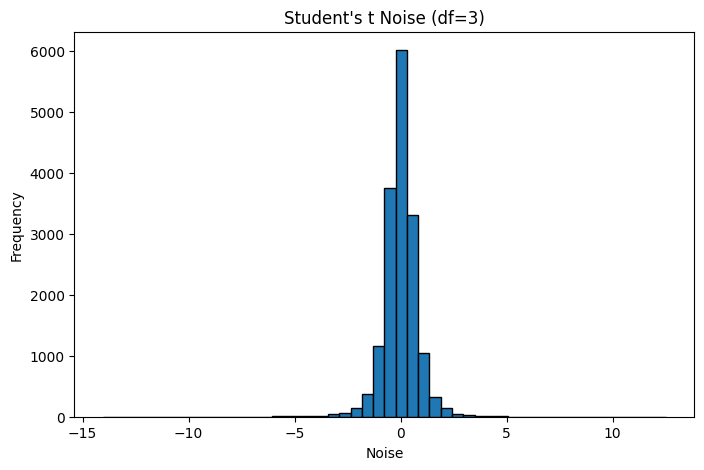

In [6]:
plt.figure(figsize=(8,5))

plt.hist(
    heavy_noise,
    bins=50,
    edgecolor="black"
)

plt.xlabel("Noise")
plt.ylabel("Frequency")
plt.title("Student's t Noise (df=3)")

plt.tight_layout()

plt.savefig(
    "heavy_noise_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

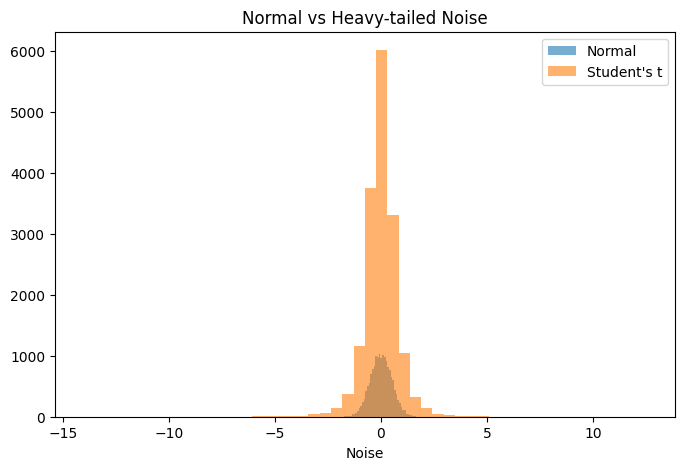

In [7]:
plt.figure(figsize=(8,5))

plt.hist(
    normal_noise,
    bins=50,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    heavy_noise,
    bins=50,
    alpha=0.6,
    label="Student's t"
)

plt.legend()

plt.xlabel("Noise")
plt.title("Normal vs Heavy-tailed Noise")

plt.tight_layout()

plt.savefig(
    "noise_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
ols = LinearRegression()

ridge = Ridge(alpha=1.0)

lasso = Lasso(alpha=0.01)

huber = HuberRegressor()

ols.fit(X_train_scaled, y_train_heavy)

ridge.fit(X_train_scaled, y_train_heavy)

lasso.fit(X_train_scaled, y_train_heavy)

huber.fit(X_train_scaled, y_train_heavy)

ols_pred = ols.predict(X_test_scaled)

ridge_pred = ridge.predict(X_test_scaled)

lasso_pred = lasso.predict(X_test_scaled)

huber_pred = huber.predict(X_test_scaled)

In [11]:
results = []

models = {
    "OLS": ols,
    "Ridge": ridge,
    "LASSO": lasso,
    "Huber": huber
}

predictions = {
    "OLS": ols_pred,
    "Ridge": ridge_pred,
    "LASSO": lasso_pred,
    "Huber": huber_pred
}

for name in models:

    pred = predictions[name]

    results.append({

        "Model": name,

        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),

        "MAE": mean_absolute_error(y_test, pred),

        "R2": r2_score(y_test, pred)

    })

metrics_df = pd.DataFrame(results)

metrics_df


In [ ]:
metrics_df.to_csv(
    "heavy_noise_metrics.csv",
    index=False
)

In [12]:
coef_df = pd.DataFrame({

    "Feature": feature_names,

    "OLS": ols.coef_,

    "Ridge": ridge.coef_,

    "LASSO": lasso.coef_,

    "Huber": huber.coef_

})

coef_df

In [ ]:
coef_df.to_csv(
    "heavy_noise_coefficients.csv",
    index=False
)

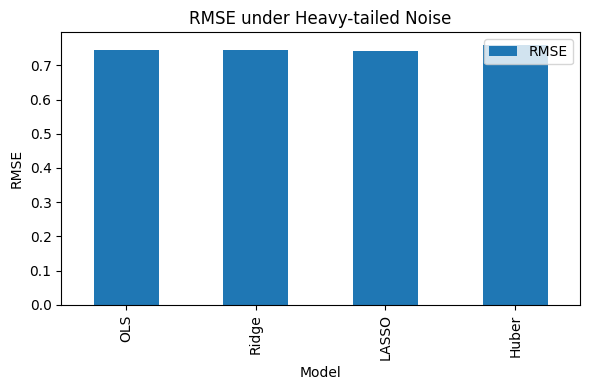

In [16]:
metrics_df.plot(
    x="Model",
    y="RMSE",
    kind="bar",
    figsize=(6,4)
)

plt.ylabel("RMSE")
plt.title("RMSE under Heavy-tailed Noise")

plt.tight_layout()

plt.savefig(
    "heavy_noise_rmse.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

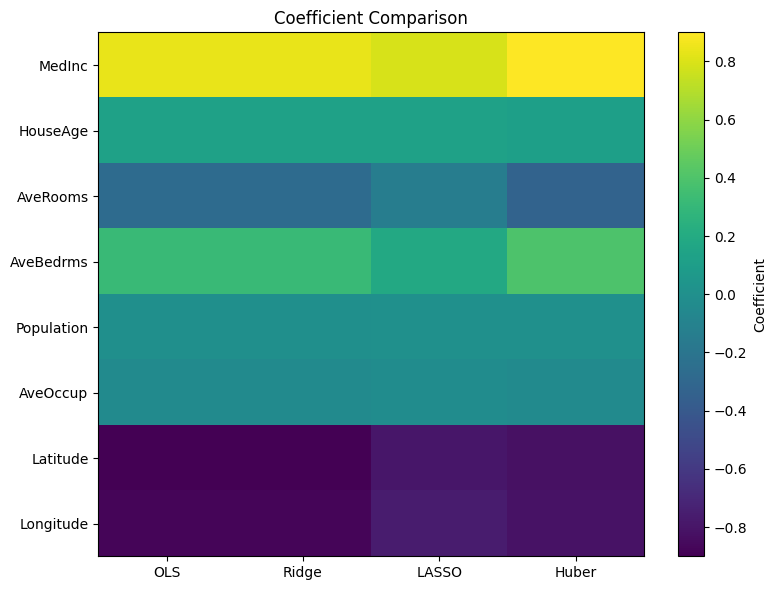

In [17]:
coef_plot = coef_df.set_index("Feature")

plt.figure(figsize=(8,6))

plt.imshow(
    coef_plot,
    aspect="auto"
)

plt.xticks(
    range(len(coef_plot.columns)),
    coef_plot.columns
)

plt.yticks(
    range(len(coef_plot.index)),
    coef_plot.index
)

plt.colorbar(label="Coefficient")

plt.title("Coefficient Comparison")

plt.tight_layout()

plt.savefig(
    "heavy_noise_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

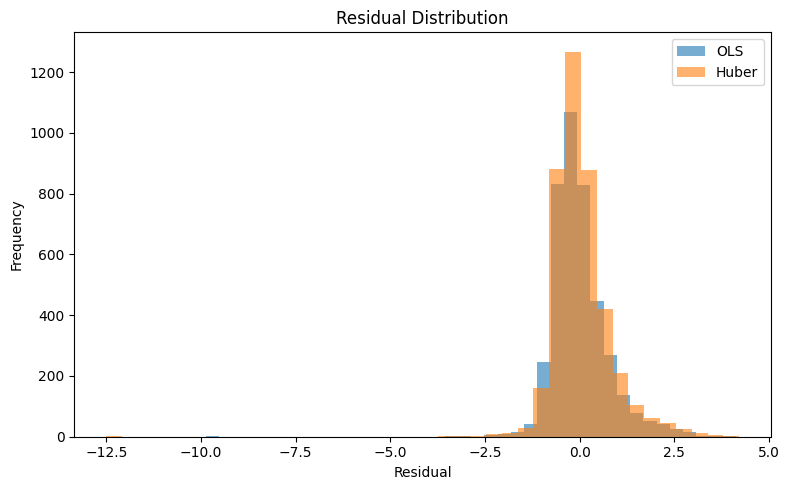

In [18]:
plt.figure(figsize=(8,5))

plt.hist(
    y_test-ols_pred,
    bins=40,
    alpha=0.6,
    label="OLS"
)

plt.hist(
    y_test-huber_pred,
    bins=40,
    alpha=0.6,
    label="Huber"
)

plt.legend()

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.title("Residual Distribution")

plt.tight_layout()

plt.savefig(
    "heavy_noise_residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

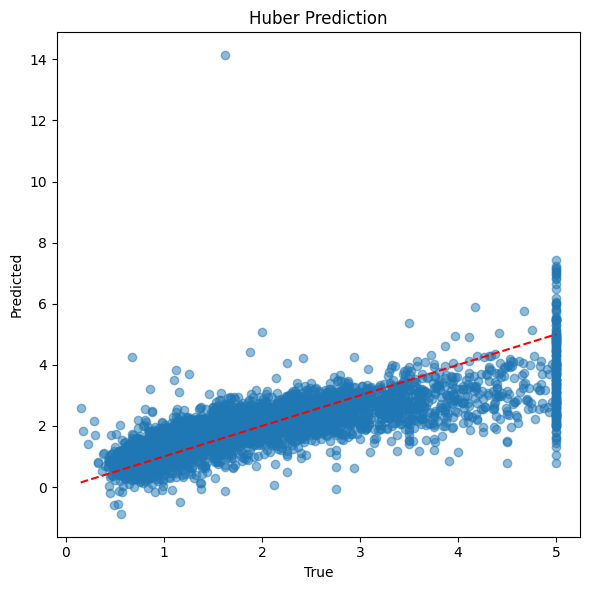

In [19]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    huber_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("True")
plt.ylabel("Predicted")

plt.title("Huber Prediction")

plt.tight_layout()

plt.savefig(
    "heavy_noise_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

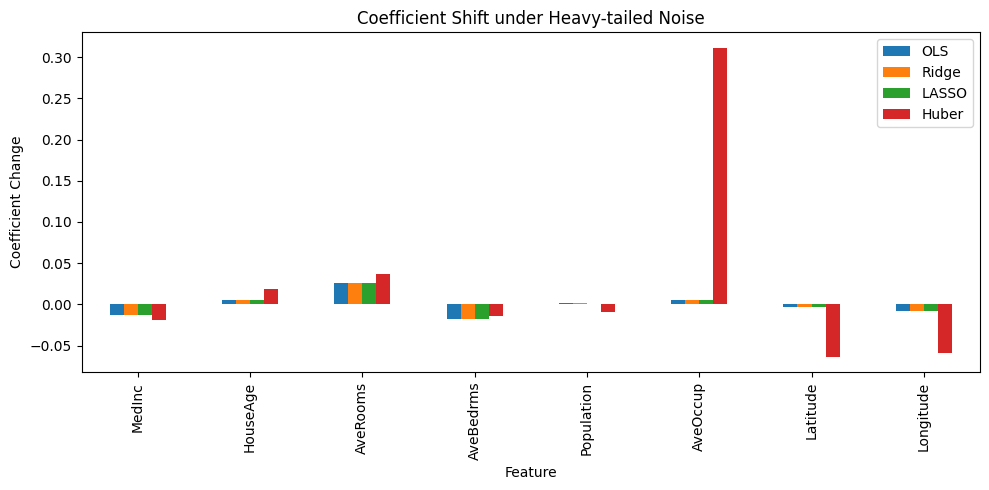

In [20]:
baseline_coef = pd.read_csv(
    "/Users/dahee/Desktop/Github/robust-regression-comparison/notebooks/baseline_coefficients.csv"
)

feature_coef = pd.read_csv(
    "/Users/dahee/Desktop/Github/robust-regression-comparison/notebooks/feature_coefficients.csv"
)

baseline_coef = baseline_coef.set_index("Feature")
heavy_coef = coef_df.set_index("Feature")

coef_change = heavy_coef - baseline_coef

coef_change.plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylabel("Coefficient Change")

plt.title("Coefficient Shift under Heavy-tailed Noise")

plt.tight_layout()

plt.savefig(
    "heavy_noise_coef_change.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()